c:\Users\rozsa\VisualStudioCodeProjects\.thesis-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training fresh model...
Calculating SHAP values natively inside XGBoost (bypassing the shap library)...
Drawing plots...


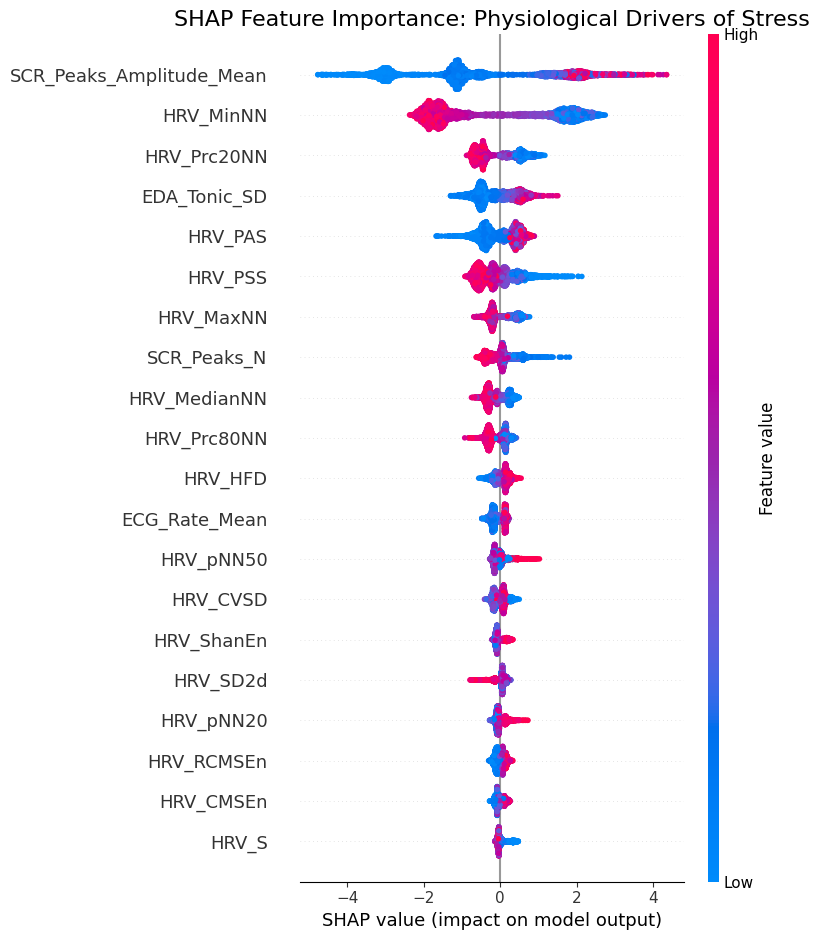

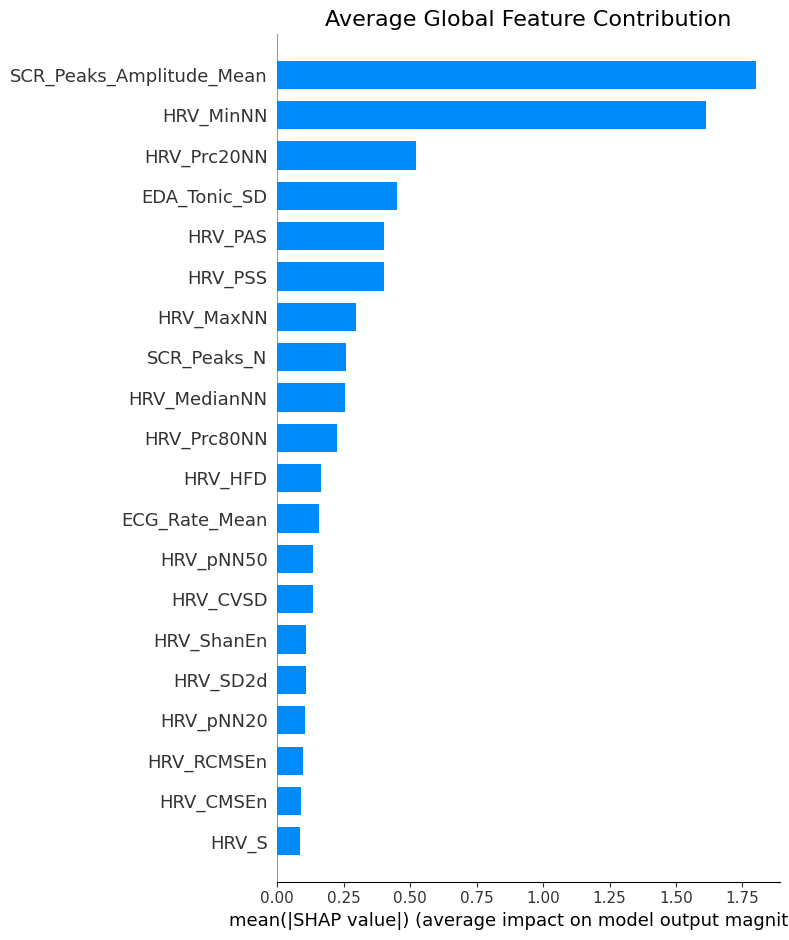

Interpretability analysis complete! Plots generated.


In [ ]:
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('wesad_final_normalized_features.csv')

ecg_cols = [c for c in df.columns if 'HRV' in c or 'ECG_Rate' in c]
gsr_cols = [c for c in df.columns if 'SCR' in c or 'EDA' in c]
fusion_cols = ecg_cols + gsr_cols

X = df[fusion_cols]
y = df['label'].map({1: 0, 2: 1})
valid_idx = y.notnull()
X = X[valid_idx]
y = y[valid_idx]

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X, y)

booster = model.get_booster()
dmatrix = xgb.DMatrix(X)

shap_matrix = booster.predict(dmatrix, pred_contribs=True)

# Separate the SHAP values from the bias column
shap_values = shap_matrix[:, :-1] 
# ------------------------------------------------

print("Drawing plots...")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP Feature Importance: Physiological Drivers of Stress', fontsize=16)
plt.tight_layout()
plt.savefig('thesis_shap_beeswarm.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title('Average Global Feature Contribution', fontsize=16)
plt.tight_layout()
plt.savefig('thesis_shap_feature_importance.png', dpi=300)
plt.show()

print("Interpretability analysis complete! Plots generated.")